<a href="https://colab.research.google.com/github/ada06052005/Analytical_Study_of_Water_Pollution_Across_Multiple_Water_Bodies/blob/main/Lake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/Lake .csv")
df

,Type Water Body,State Name,Mean(Temp),Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),WQI,Year
0,LAKE,ANDHRA \nPRADESH,24.50,5.20,7.50,872.0,2.60,3.115,1274.5,61,2022
1,LAKE,ANDHRA \nPRADESH,23.50,5.95,7.90,1007.5,3.85,1.740,335.0,61,2022
2,LAKE,ANDHRA \nPRADESH,27.50,4.90,7.80,645.0,3.60,1.770,195.0,51,2022
3,LAKE,ANDHRA \nPRADESH,25.00,5.60,7.20,428.5,1.85,0.790,768.5,56,2022
4,LAKE,ANDHRA \nPRADESH,20.00,6.25,7.75,36650.0,2.75,1.445,382.0,237,2022
...,...,...,...,...,...,...,...,...,...,...,...
1621,LAKE,WEST BENGAL,12.00,6.70,7.50,142.5,3.00,0.450,15500.0,171,2018
1622,LAKE,WEST BENGAL,16.50,7.85,7.50,38.0,1.70,0.300,830.0,69,2018
1623,LAKE,WEST BENGAL,10.00,8.00,7.65,26.5,1.35,0.250,770.0,69,2018
1624,LAKE,WEST BENGAL,26.00,6.90,7.50,211.0,2.15,0.650,7700.0,115,2018


In [ ]:
try:
    data = pd.ExcelFile(file_path)
    # Display sheet names to understand the structure
    sheet_names = data.sheet_names
    sheet_names
except Exception as e:
    str(e)



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1626 entries, 0 to 1625
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Type Water Body       1626 non-null   object 
 1   State Name            1626 non-null   object 
 2   Mean(Temp)            1626 non-null   float64
 3   Mean (DO)             1626 non-null   float64
 4   Mean(pH)              1626 non-null   float64
 5   Mean conductivity)    1626 non-null   float64
 6   Mean(BOD)             1626 non-null   float64
 7   Mean Nitrite)         1626 non-null   float64
 8   Mean(total coliform)  1626 non-null   float64
 9   WQI                   1626 non-null   int64  
 10  Year                  1626 non-null   int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 139.9+ KB


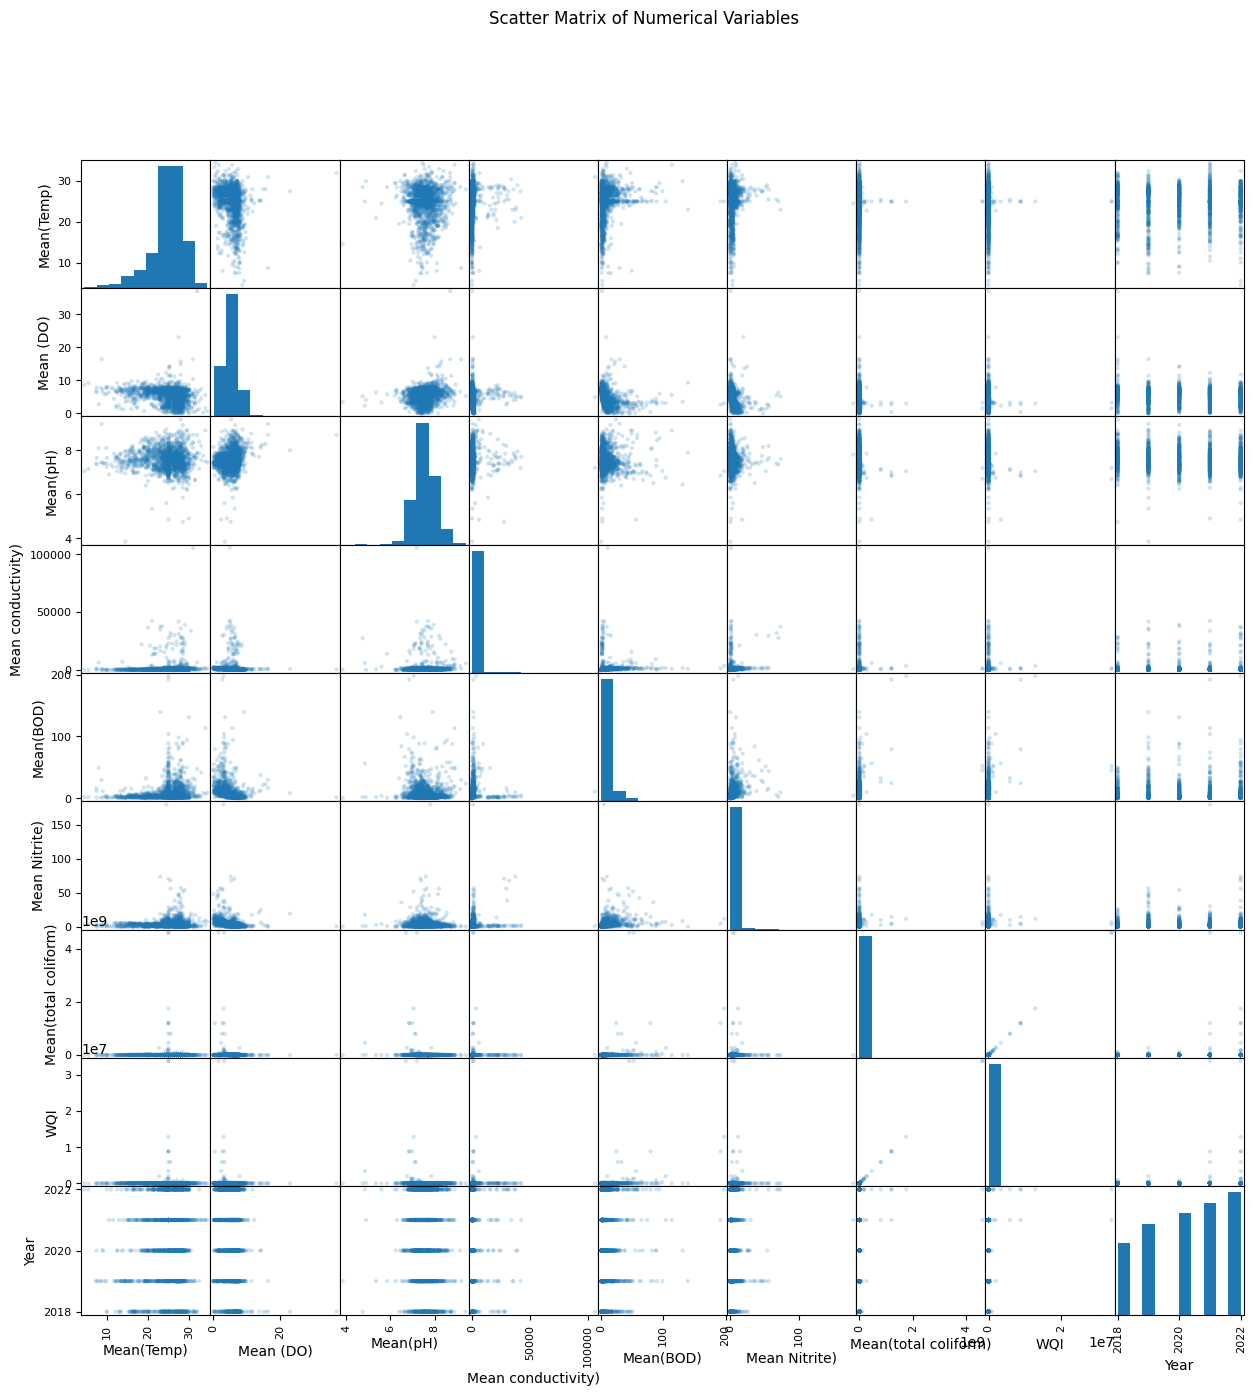

,Mean(Temp),Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),WQI,Year
count,1626.000000,1626.000000,1626.000000,1626.000000,1626.000000,1626.000000,1.626000e+03,1.626000e+03,1626.000000
mean,24.635154,5.348186,7.555750,1537.043756,9.266313,4.036408,1.202171e+07,8.853902e+04,2020.247847
std,4.091948,2.439312,0.474973,5013.304746,14.898332,7.536149,1.776694e+08,1.307648e+06,1.378766
min,4.500000,0.050000,3.850000,5.000000,0.100000,0.000000,2.000000e+00,1.900000e+01,2018.000000
25%,23.275000,3.700000,7.250000,256.500000,2.100000,0.800000,2.900000e+02,5.700000e+01,2019.000000
50%,25.000000,5.700000,7.550000,599.500000,4.000000,2.280000,1.260000e+03,7.100000e+01,2020.000000
75%,27.500000,6.900000,7.850000,1117.125000,10.500000,4.550000,1.300000e+04,2.017500e+02,2021.000000
max,34.500000,37.000000,9.400000,105650.000000,197.500000,179.900000,4.600018e+09,3.385619e+07,2022.000000


In [ ]:
import matplotlib.pyplot as plt

# Summarize numerical data to review key statistics
numerical_summary = df.describe()

# Plot pairwise relationships to check for linear trends with the target variable (WQI)
pd.plotting.scatter_matrix(df.select_dtypes(include=['float64', 'int64']), alpha=0.2, figsize=(15, 15), diagonal='hist')
plt.suptitle("Scatter Matrix of Numerical Variables")
plt.show()

numerical_summary

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical predictors and the target variable
predictor_columns = [ 'Mean (DO)', 'Mean(pH)', 'Mean conductivity)',
                     'Mean(BOD)', 'Mean Nitrite)', 'Mean(total coliform)']
target_column = 'WQI'

# Extract predictors and target
X = df[predictor_columns]
y = df[target_column]

# Scaling predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled predictors back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=predictor_columns)

# Display first few rows of scaled data
X_scaled_df.head()


,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform)
0,-0.060768,-0.117412,-0.132697,-0.447591,-0.122303,-0.067677
1,0.246791,0.725001,-0.105660,-0.363663,-0.304813,-0.067682
2,-0.183791,0.514397,-0.177990,-0.380449,-0.300831,-0.067683
3,0.103263,-0.749221,-0.221188,-0.497948,-0.430911,-0.067680
4,0.369814,0.409096,7.006109,-0.437520,-0.343970,-0.067682


In [ ]:
#Variance inflation factor = to chack multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = predictor_columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data

,Variable,VIF
0,Mean (DO),1.244945
1,Mean(pH),1.055893
2,Mean conductivity),1.016284
3,Mean(BOD),1.237584
4,Mean Nitrite),1.128441
5,Mean(total coliform),1.085482


In [ ]:
import statsmodels.api as sm

# Add a constant to the predictors for the regression model
X_with_const = sm.add_constant(X_scaled)

# Fit the regression model
model = sm.OLS(y, X_with_const).fit()

# Summarize the regression results
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.626e+15
Date:                Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                        14:28:23   Log-Likelihood:                -273.49
No. Observations:                1626   AIC:                             561.0
Df Residuals:                    1619   BIC:                             598.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.854e+04      0.007   1.24e+07      0.000    8.85e+04    8.85e+04
x1            14.3555      0.008   1808.247      0.000      14.340      14.371
x2             0.9790      0.007    133.903      0.000       0.965       0.993
x3            24.5934      0.007   3428.663      0.000      24.579      24.607
x4             7.3005      0.008    922.318      0.000       7.285       7.316
x5             0.4427      0.008     58.570      0.000       0.428       0.458
x6          1.307e+06      0.007   1.76e+08      0.000    1.31e+06    1.31e+06
==============================================================================
Omnibus:                     1131.818   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.279
Skew:                           0.022   Prob(JB):                     2.04e-21
Kurtosis:                       1.815   Cond. No.                         1.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

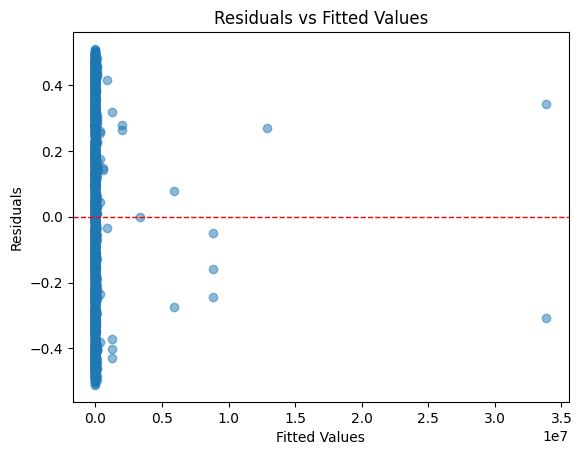

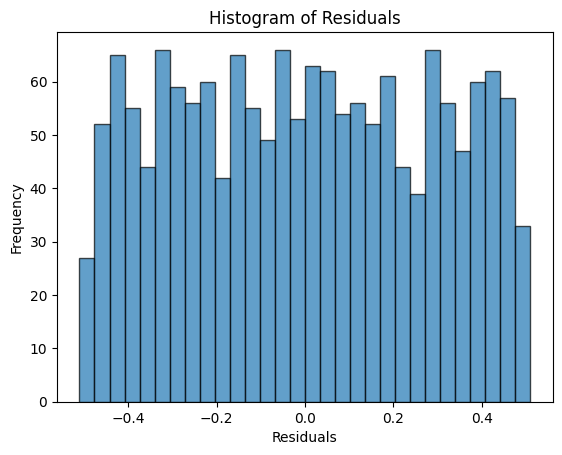

(ShapiroResult(statistic=0.9559898683325564, pvalue=9.755701667800844e-22),
 NormaltestResult(statistic=1131.818200570373, pvalue=1.6935596089858404e-246))

In [ ]:
import numpy as np

# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# Plot residuals vs fitted values to check homoscedasticity
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot histogram of residuals to check normality
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Perform statistical tests for normality
from scipy.stats import shapiro, normaltest

shapiro_test = shapiro(residuals)
normal_test = normaltest(residuals)

shapiro_test, normal_test


In [ ]:
# Calculate skewness for each predictor and the target variable
skewness = df[predictor_columns + [target_column]].skew()

# Select variables with high skewness (absolute skewness > 1)
high_skew_vars = skewness[abs(skewness) > 1].index.tolist()
skewness


,0
Mean (DO),1.510549
Mean(pH),-0.422500
Mean conductivity),9.423170
Mean(BOD),5.231178
Mean Nitrite),10.795577
Mean(total coliform),22.472330
WQI,22.472302


In [ ]:
# Apply log transformation to highly skewed variables (adding 1 to avoid log(0))
transformed_df = df.copy()
for col in high_skew_vars:
    transformed_df[col] = np.log1p(transformed_df[col])

# Scale predictors after transformation
X_transformed = transformed_df[predictor_columns]
y_transformed = transformed_df[target_column]
X_scaled_transformed = scaler.fit_transform(X_transformed)

# Add constant for regression
X_transformed_const = sm.add_constant(X_scaled_transformed)

# Fit the regression model with transformed data
model_transformed = sm.OLS(y_transformed, X_transformed_const).fit()

# Summarize the transformed regression results
transformed_model_summary = model_transformed.summary()
transformed_model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     1617.
Date:                Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                        14:28:46   Log-Likelihood:                -2032.7
No. Observations:                1626   AIC:                             4079.
Df Residuals:                    1619   BIC:                             4117.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2518      0.021    250.176      0.000       5.211       5.293
x1             0.1904      0.030      6.406      0.000       0.132       0.249
x2            -0.0819      0.023     -3.580      0.000      -0.127      -0.037
x3             0.2036      0.025      8.254      0.000       0.155       0.252
x4             0.0305      0.032      0.949      0.343      -0.033       0.094
x5            -0.0437      0.026     -1.661      0.097      -0.095       0.008
x6             2.0183      0.026     77.305      0.000       1.967       2.070
==============================================================================
Omnibus:                      226.122   Durbin-Watson:                   1.260
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              335.445
Skew:                           0.995   Prob(JB):                     1.44e-73
Kurtosis:                       3.997   Cond. No.                         3.16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Example input for prediction
new_data = pd.DataFrame({
    'Mean (DO)': [5.1],
    'Mean(pH)': [6.9],
    'Mean conductivity)': [1187],
    'Mean(BOD)': [3.9],
    'Mean Nitrite)': [12],
    'Mean(total coliform)': [3200]
})

# Apply log transformations to predictors
for col in ['Mean conductivity)', 'Mean(BOD)', 'Mean Nitrite)',
            'Mean(total coliform)']:
    new_data[col] = np.log1p(new_data[col])

# Scale the predictors
new_scaled = scaler.transform(new_data)

# Add constant for prediction - Correcting the use of sm.add_constant
new_with_const = sm.add_constant(new_scaled, has_constant='add')

# Predict WQI using the transformed model - Using the correct model name
predicted_wqi = model_transformed.predict(new_with_const) # log_transformed_model should be model_transformed

# Reverse transformation for WQI if needed
predicted_wqi_original_scale = np.expm1(predicted_wqi)
predicted_wqi_original_scale

array([889.15406995])